In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import pycountry
import copy
from matplotlib.gridspec import GridSpec
from matplotlib import ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FormatStrFormatter

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
path_water_fall = os.path.join('..', 'Results', 'Chemical industry emissions.xlsx')

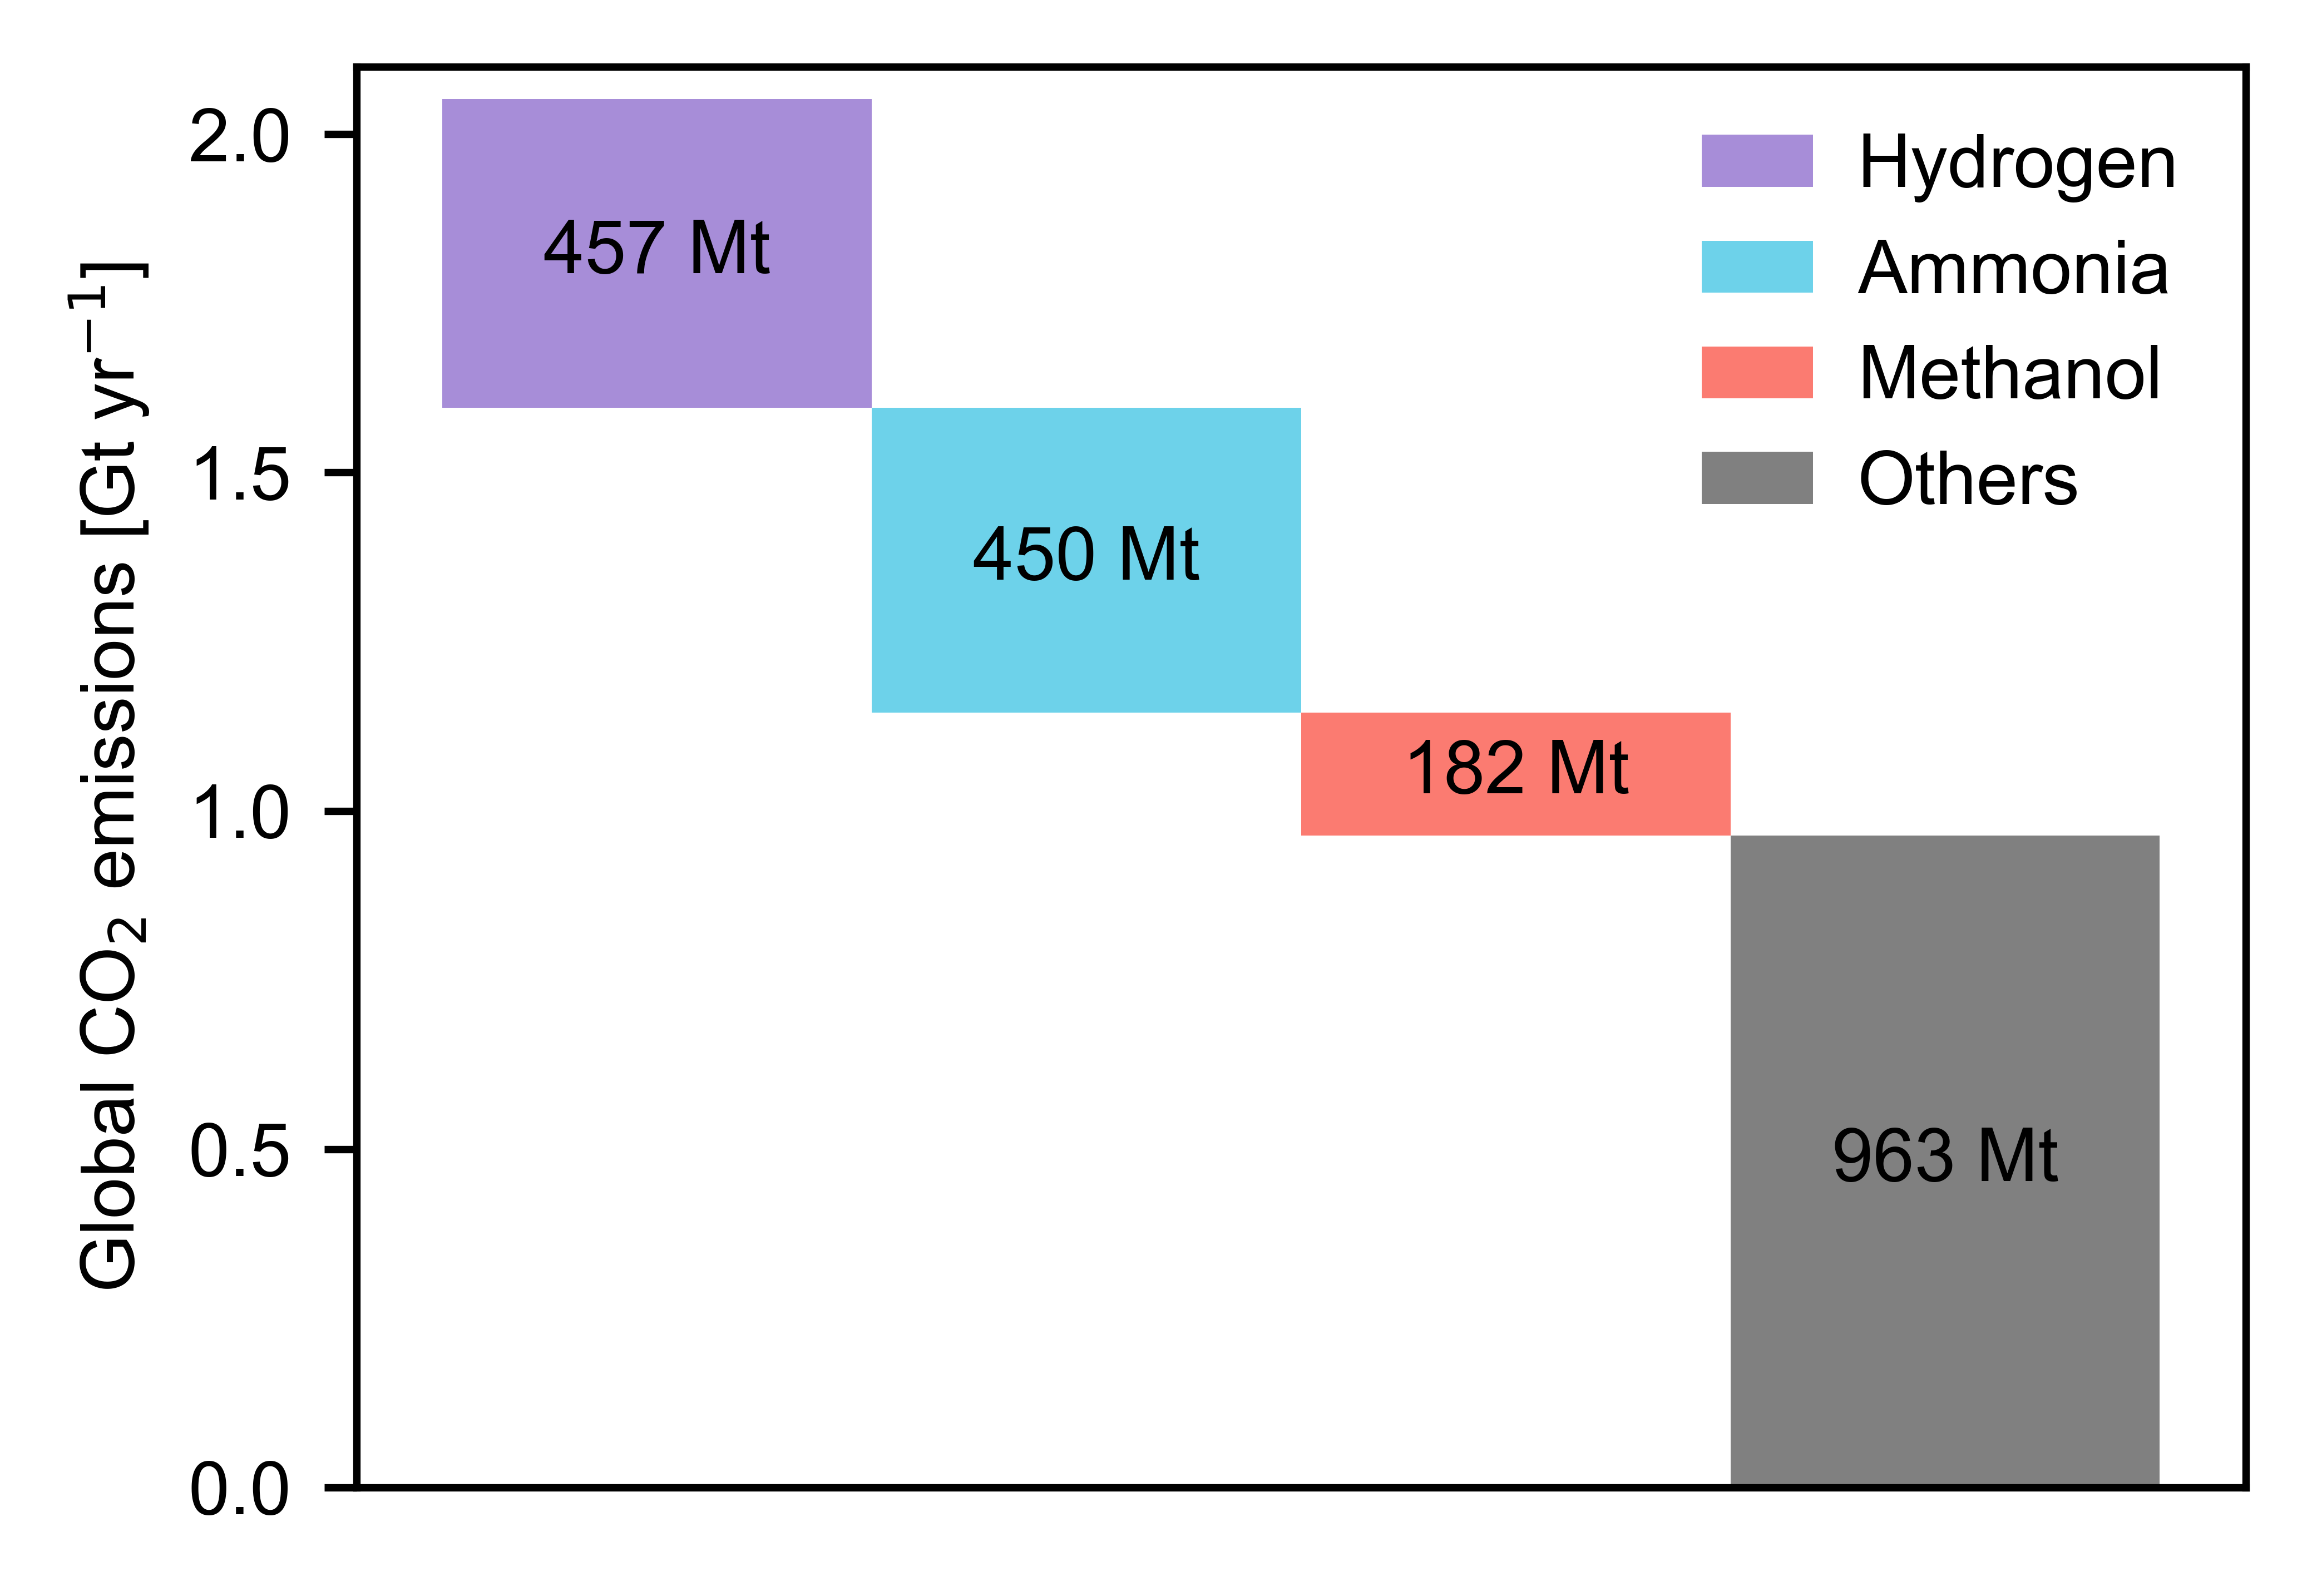

In [4]:
# water fall plot RER cradle to gate
waterFallDF = pd.read_excel(path_water_fall, sheet_name = 'Waterfall final data', header = None)

plt.figure(figsize = (fig_length[1], fig_height*0.25), dpi = 1200)

# data here is loaded manually and based on BioSNG_comparison.xlsx
# x is the number of bars
# y is the size of the bars
# z is the starting point of the bars on the y axis 
# w is the total that needs to be read
y = waterFallDF.iloc[1]/1000
z = waterFallDF.iloc[2]/1000
w = waterFallDF.iloc[0]/1000

f = pd.DataFrame({"x": range(4), "y": y[1:], 'z': z[1:], 'w':w[1:]})
# color bar is the same as clr but with BAU in first place
colors_bars = ['#a78dd8','#6dd2ea','#fb7b71', '#808080']
labels = ['Hydrogen', 'Ammonia', 'Methanol', 'Others']
text = labels

# main plot 
handle2 = plt.bar(f.x, f.y, bottom= f.z, color = colors_bars, zorder = 2, label = labels, width = 1)

# Set y=0 line
# handle3 = plt.axhline(y = 0, color = 'k', linestyle = '-', zorder=1, linewidth=0.3)

# set the total
# handle1 = plt.scatter(f.x, f.w, color = '#008489', marker = 'D', s = 5, zorder = 3)
# handle1 = plt.plot(f.x, f.w, color = '#008489', linestyle = '--', linewidth = 0.5)

ax = plt.gca()

# Set ax lines thinner and remove ax2 lines
#for axis in ['top','bottom','left','right']:
#        ax.spines[axis].set_linewidth(0.3)

for i, (x_val, y_val, z_val) in enumerate(zip(f.x, f.y, f.z)):
    y = y_val * 1000
    plt.text(x_val, y_val / 2 + z_val, str(abs(round(y))) + ' Mt', ha='center', va='center', color='black')

ax.set_xticklabels([])
ax.set_xticks([])
ax.set_ylim(bottom=0, top=2.1)
ax.set_ylabel('Global CO$_\mathrm{2}$ emissions [Gt yr$^\mathrm{-1}$]')
ax.yaxis.set_major_locator(MaxNLocator(5))

# ax.set_title('a', color = 'black', fontweight = 'bold', fontsize = fontsize_title)

legend = plt.legend(frameon = False, handletextpad = 0.1, ncol = 1, fontsize=8)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

plt.savefig(os.path.join('..', 'Results', 'Global emissions.svg'), bbox_inches='tight')
plt.savefig(os.path.join('..', 'Results', 'Global emissions.png'), bbox_inches='tight')